In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_naoh = np.loadtxt("data_naoh.txt").T
sum = 0
for i in range(len(data_naoh[0])):
    sum += data_naoh[0][i]
    data_naoh[0][i] = sum
    
data_hcl = np.loadtxt("data_hcl.txt").T
sum = 0
for i in range(len(data_hcl[0])):
    sum += data_hcl[0][i]
    data_hcl[0][i] = -sum

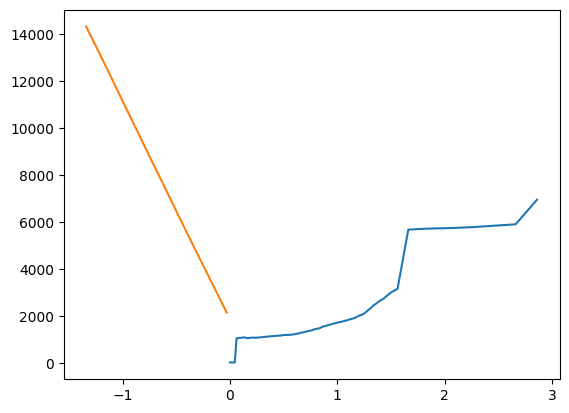

In [136]:
plt.plot(data_naoh[0], data_naoh[2])
plt.plot(data_hcl[0][:-6], data_hcl[2][:-6])

(np.float64(0.26000000000000023), np.float64(1.5550000000000002))
(np.float64(0.34999999999999926), np.float64(1.655))
(np.float64(0.4), np.float64(1.71))
(np.float64(0.4), np.float64(1.74))
(np.float64(0.4), np.float64(1.76))
(np.float64(0.4000000000000009), np.float64(1.78))
(np.float64(0.4), np.float64(1.8))
(np.float64(0.6), np.float64(1.8250000000000002))
(np.float64(0.4), np.float64(1.85))
(np.float64(0.5999999999999955), np.float64(1.875))
(np.float64(0.6), np.float64(1.9049999999999998))
(np.float64(0.6), np.float64(1.935))
(np.float64(0.6), np.float64(1.9649999999999999))
(np.float64(0.8), np.float64(2.0))
(np.float64(0.8), np.float64(2.04))
(np.float64(0.8), np.float64(2.08))
(np.float64(0.9999999999999967), np.float64(2.125))
(np.float64(1.0000000000000056), np.float64(2.175))
(np.float64(1.1999999999999924), np.float64(2.23))
(np.float64(1.400000000000006), np.float64(2.295))
(np.float64(1.600000000000001), np.float64(2.37))
(np.float64(2.0000000000000013), np.float64(2.45)

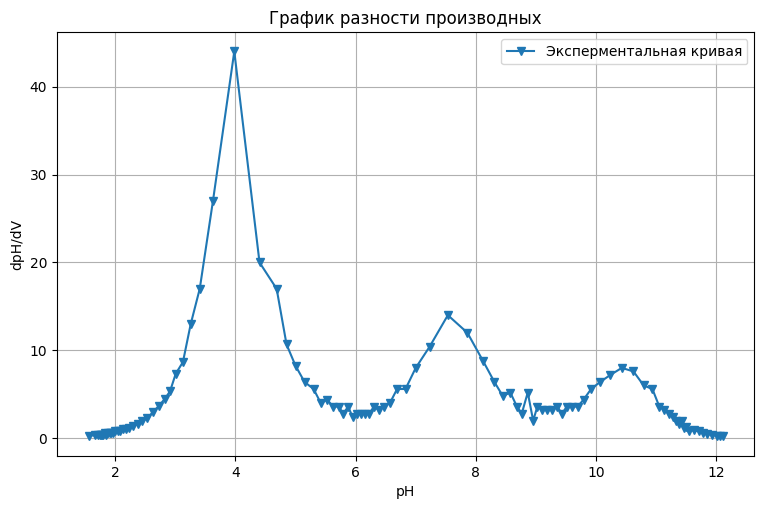

In [133]:
data_ml = np.concatenate((data_hcl[0][::-1], data_naoh[0]))
data_ph = np.concatenate((data_hcl[1][::-1], data_naoh[1]))
plt.figure(figsize=(9, 5.5))

d_ph_v = []
pH = []
for i in range(len(data_ml) - 1):
    d_ph = data_ph[i + 1] - data_ph[i]
    d_ml = data_ml[i + 1] - data_ml[i]
    d_ph_v.append(d_ph / d_ml)

    pH.append((data_ph[i + 1] + data_ph[i])/2)

plt.plot(pH, d_ph_v, 'v-', label = "Эксперментальная кривая")
plt.title("График разности производных")
plt.legend()
plt.grid()
plt.xlabel("pH")
plt.ylabel("dpH/dV")
plt.savefig("graph5.pdf")
for i in zip(d_ph_v, pH):
    print(i)

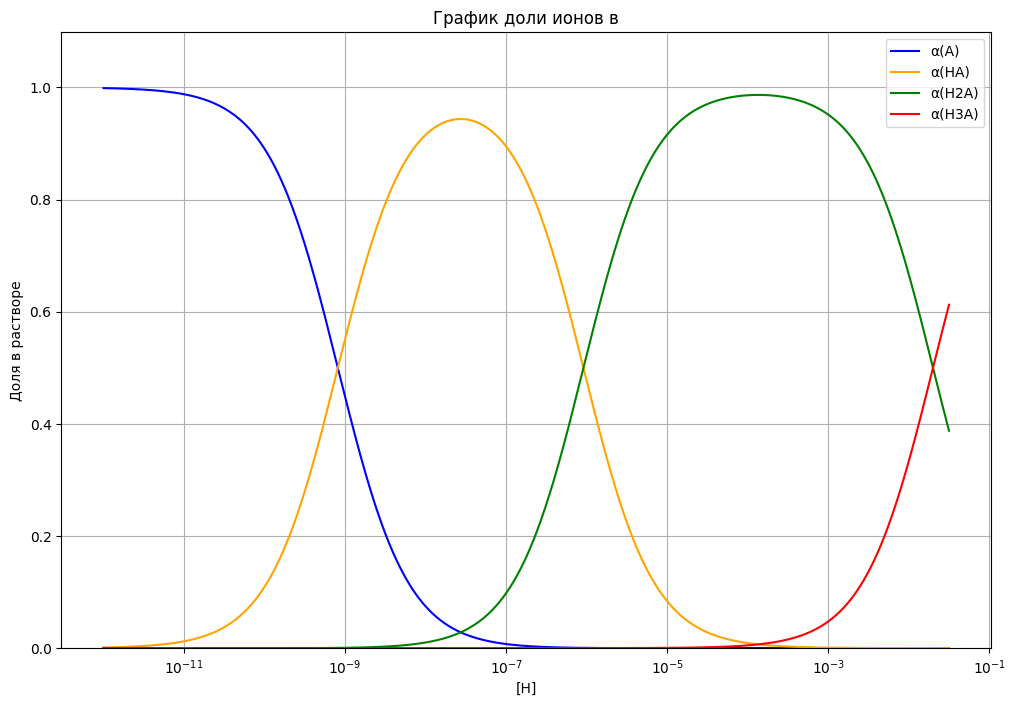

In [113]:
import numpy as np
import matplotlib.pyplot as plt

# Определение констант
k1 = 2 * 10**(-2)
k2 = 9.12 * 10**(-7)
k3 = 8.128 * 10**(-10)

# Определение диапазона x
x = np.logspace(np.log10(3.16 * 10**(-2)), np.log10(1 * 10**(-12)), 1000)

# Вычисление значений функций
denominator = k1 * k2 * k3 + k1 * k2 * x + k1 * x**2 + x**3

a1 = (k1 * k2 * k3) / denominator
a2 = (k1 * k2 * x) / denominator
a3 = (k1 * x**2) / denominator
a4 = (x**3) / denominator

# Построение графиков
plt.figure(figsize=(12, 8))
plt.plot(x, a1, label='α(A)', color='blue')
plt.plot(x, a2, label='α(HA)', color='orange')
plt.plot(x, a3, label='α(H2A)', color='green')
plt.plot(x, a4, label='α(H3A)', color='red')

# Настройка графика
plt.title('График доли ионов в')
plt.xlabel('[H]')
plt.ylabel('Доля в растворе')
plt.legend()
plt.grid()
plt.xscale('log')  # Логарифмическая шкала по оси X для лучшего отображения
plt.ylim(0, np.max([a1.max(), a2.max(), a3.max(), a4.max()]) * 1.1)  # Устанавливаем лимит по y

# Показать график
plt.savefig("graph2.pdf")

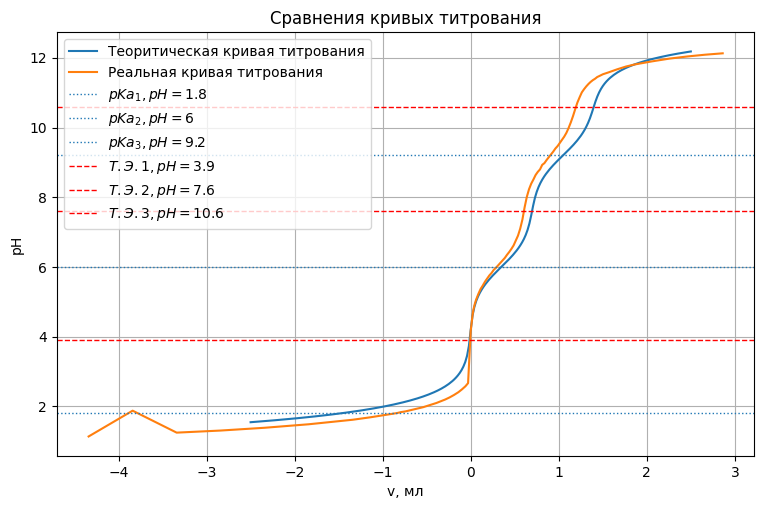

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Histidine titration simulation
# ------------------------------------------------------------
# Model:
# Histidine is treated as a triprotic acid/base system:
#   H3A2+  <->  H2A+  + H+     pKa1
#   H2A+   <->  HA    + H+     pKa2
#   HA     <->  A-    + H+     pKa3
#
# Charges:
#   H3A2+ : +2
#   H2A+  : +1
#   HA    :  0
#   A-    : -1
#
# We choose a fixed chloride background so that the initial solution
# (histidine only, no titrant added) has pH = 4.2.
# ------------------------------------------------------------

# ---- User-adjustable settings ----
V0_L = 70e-3          # initial volume, L
C_hist = 0.010        # histidine concentration, M
C_titrant = 1.0       # HCl / NaOH concentration, M
initial_pH = 4.2      # desired starting pH at 0 mL added

# Histidine pKa values (common approximate values)
pKa1 = 1.80
pKa2 = 6.00
pKa3 = 9.20

# Range of titrant added (negative = HCl, positive = NaOH)
x_mL = np.linspace(-2.5, 2.5, 241)

# ------------------------------------------------------------
# Constants
# ------------------------------------------------------------
Kw = 1.0e-14
Ka1 = 10**(-pKa1)
Ka2 = 10**(-pKa2)
Ka3 = 10**(-pKa3)

n_hist = C_hist * V0_L  # total moles histidine

# ------------------------------------------------------------
# Species distribution for triprotic histidine
# ------------------------------------------------------------
def histidine_fractions(H):
    """
    Returns alpha0..alpha3 for:
      alpha0 = H3A2+
      alpha1 = H2A+
      alpha2 = HA
      alpha3 = A-
    """
    D = H**3 + Ka1*H**2 + Ka1*Ka2*H + Ka1*Ka2*Ka3
    alpha0 = H**3 / D
    alpha1 = Ka1 * H**2 / D
    alpha2 = Ka1 * Ka2 * H / D
    alpha3 = Ka1 * Ka2 * Ka3 / D
    return alpha0, alpha1, alpha2, alpha3

def avg_histidine_charge(H):
    """
    Average charge per histidine molecule.
    """
    a0, a1, a2, a3 = histidine_fractions(H)
    return 2*a0 + 1*a1 + 0*a2 - 1*a3

# ------------------------------------------------------------
# Calibrate fixed chloride background so that pH(0 mL) = 4.2
# ------------------------------------------------------------
H0 = 10**(-initial_pH)
OH0 = Kw / H0
z0 = avg_histidine_charge(H0)

# Charge balance at start:
# [H+] + C_hist*z_avg = [OH-] + [Cl-]_fixed
# => [Cl-]_fixed = [H+] + C_hist*z_avg - [OH-]
C_Cl_fixed_0 = H0 + C_hist * z0 - OH0
n_Cl_fixed = C_Cl_fixed_0 * V0_L

if n_Cl_fixed < 0:
    raise ValueError("Computed fixed chloride background is negative. Check parameters.")

# ------------------------------------------------------------
# Charge-balance function
# ------------------------------------------------------------
def charge_balance(logH, Vadd_mL):
    """
    Returns f(logH) = positive charge - negative charge.
    Root of this function gives the pH.
    """
    H = 10**logH
    OH = Kw / H

    Vadd_L = abs(Vadd_mL) * 1e-3
    Vtot = V0_L + Vadd_L

    n_HCl = max(-Vadd_mL, 0.0) * 1e-3 * C_titrant
    n_NaOH = max(Vadd_mL, 0.0) * 1e-3 * C_titrant

    C_hist_tot = n_hist / Vtot
    C_Na = n_NaOH / Vtot
    C_Cl = (n_Cl_fixed + n_HCl) / Vtot

    z = avg_histidine_charge(H)

    # Positive charges - negative charges
    return (H + C_Na + C_hist_tot * z) - (OH + C_Cl)

# ------------------------------------------------------------
# Simple bisection solver in log10[H+]
# ------------------------------------------------------------
def solve_pH(Vadd_mL, lo=-14.0, hi=0.0, tol=1e-12, max_iter=200):
    flo = charge_balance(lo, Vadd_mL)
    fhi = charge_balance(hi, Vadd_mL)

    if flo == 0:
        return -lo
    if fhi == 0:
        return -hi

    # Try to bracket the root more robustly if needed
    if flo * fhi > 0:
        grid = np.linspace(-16, 1, 500)
        vals = [charge_balance(g, Vadd_mL) for g in grid]
        for i in range(len(grid) - 1):
            if vals[i] == 0:
                return -grid[i]
            if vals[i] * vals[i + 1] < 0:
                lo, hi = grid[i], grid[i + 1]
                flo, fhi = vals[i], vals[i + 1]
                break
        else:
            raise RuntimeError(f"Could not bracket root for Vadd = {Vadd_mL:.3f} mL")

    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        fmid = charge_balance(mid, Vadd_mL)

        if abs(fmid) < tol:
            return -mid

        if flo * fmid < 0:
            hi = mid
            fhi = fmid
        else:
            lo = mid
            flo = fmid

    return -0.5 * (lo + hi)

# ------------------------------------------------------------
# Calculate pH values
# ------------------------------------------------------------
pH_values = np.array([solve_pH(v) for v in x_mL])

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(9, 5.5))
plt.xlabel("v, мл")
plt.ylabel("pH")
plt.grid()

plt.plot(x_mL, pH_values, label="Теоритическая кривая титрования")


plt.plot(np.concatenate((data_hcl[0][::-1], data_naoh[0])), np.concatenate((data_hcl[1][::-1], data_naoh[1])), label="Реальная кривая титрования")
plt.axhline(1.8, linestyle=":", linewidth=1, label=r"$pKa_1, pH = 1.8$")
plt.axhline(6, linestyle=":", linewidth=1, label=r"$pKa_2, pH = 6$")
plt.axhline(9.2, linestyle=":", linewidth=1, label=r"$pKa_3, pH = 9.2$")

plt.axhline(3.9, linestyle="--", color="red", linewidth=1, label=r"$Т.Э. 1, pH = 3.9$")
plt.axhline(7.6, linestyle="--", color="red", linewidth=1, label=r"$Т.Э. 2, pH = 7.6$")
plt.axhline(10.6, linestyle="--", color="red", linewidth=1, label=r"$Т.Э. 3, pH = 10.6$")
plt.title("Сравнения кривых титрования")
plt.legend()
plt.savefig("graph4.pdf")